## 1) Environment Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, entropy
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.ensemble import RandomForestClassifier

## 2) Load and Inspect Mushroom Dataset

In [2]:
df_raw = pd.read_csv("../../Mushroom Dataset/mushrooms 2.csv")

display(df_raw.head())
print('Shape:', df_raw.shape)

print('\nGeneral information:')
display(df_raw.info())

print('\nSummary (object columns):')
display(df_raw.describe(include='all'))

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


Shape: (8124, 23)

General information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-nul

None


Summary (object columns):


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148



Target distribution:


class
e    4208
p    3916
Name: count, dtype: int64

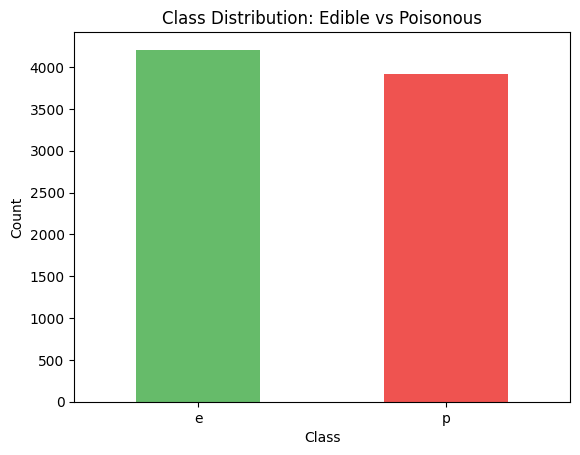

In [3]:
print('\nTarget distribution:')
display(df_raw['class'].value_counts())

plt.figure()
df_raw["class"].value_counts().plot( kind="bar", color=["#66bb6a", "#ef5350"], rot=0)
plt.title("Class Distribution: Edible vs Poisonous")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

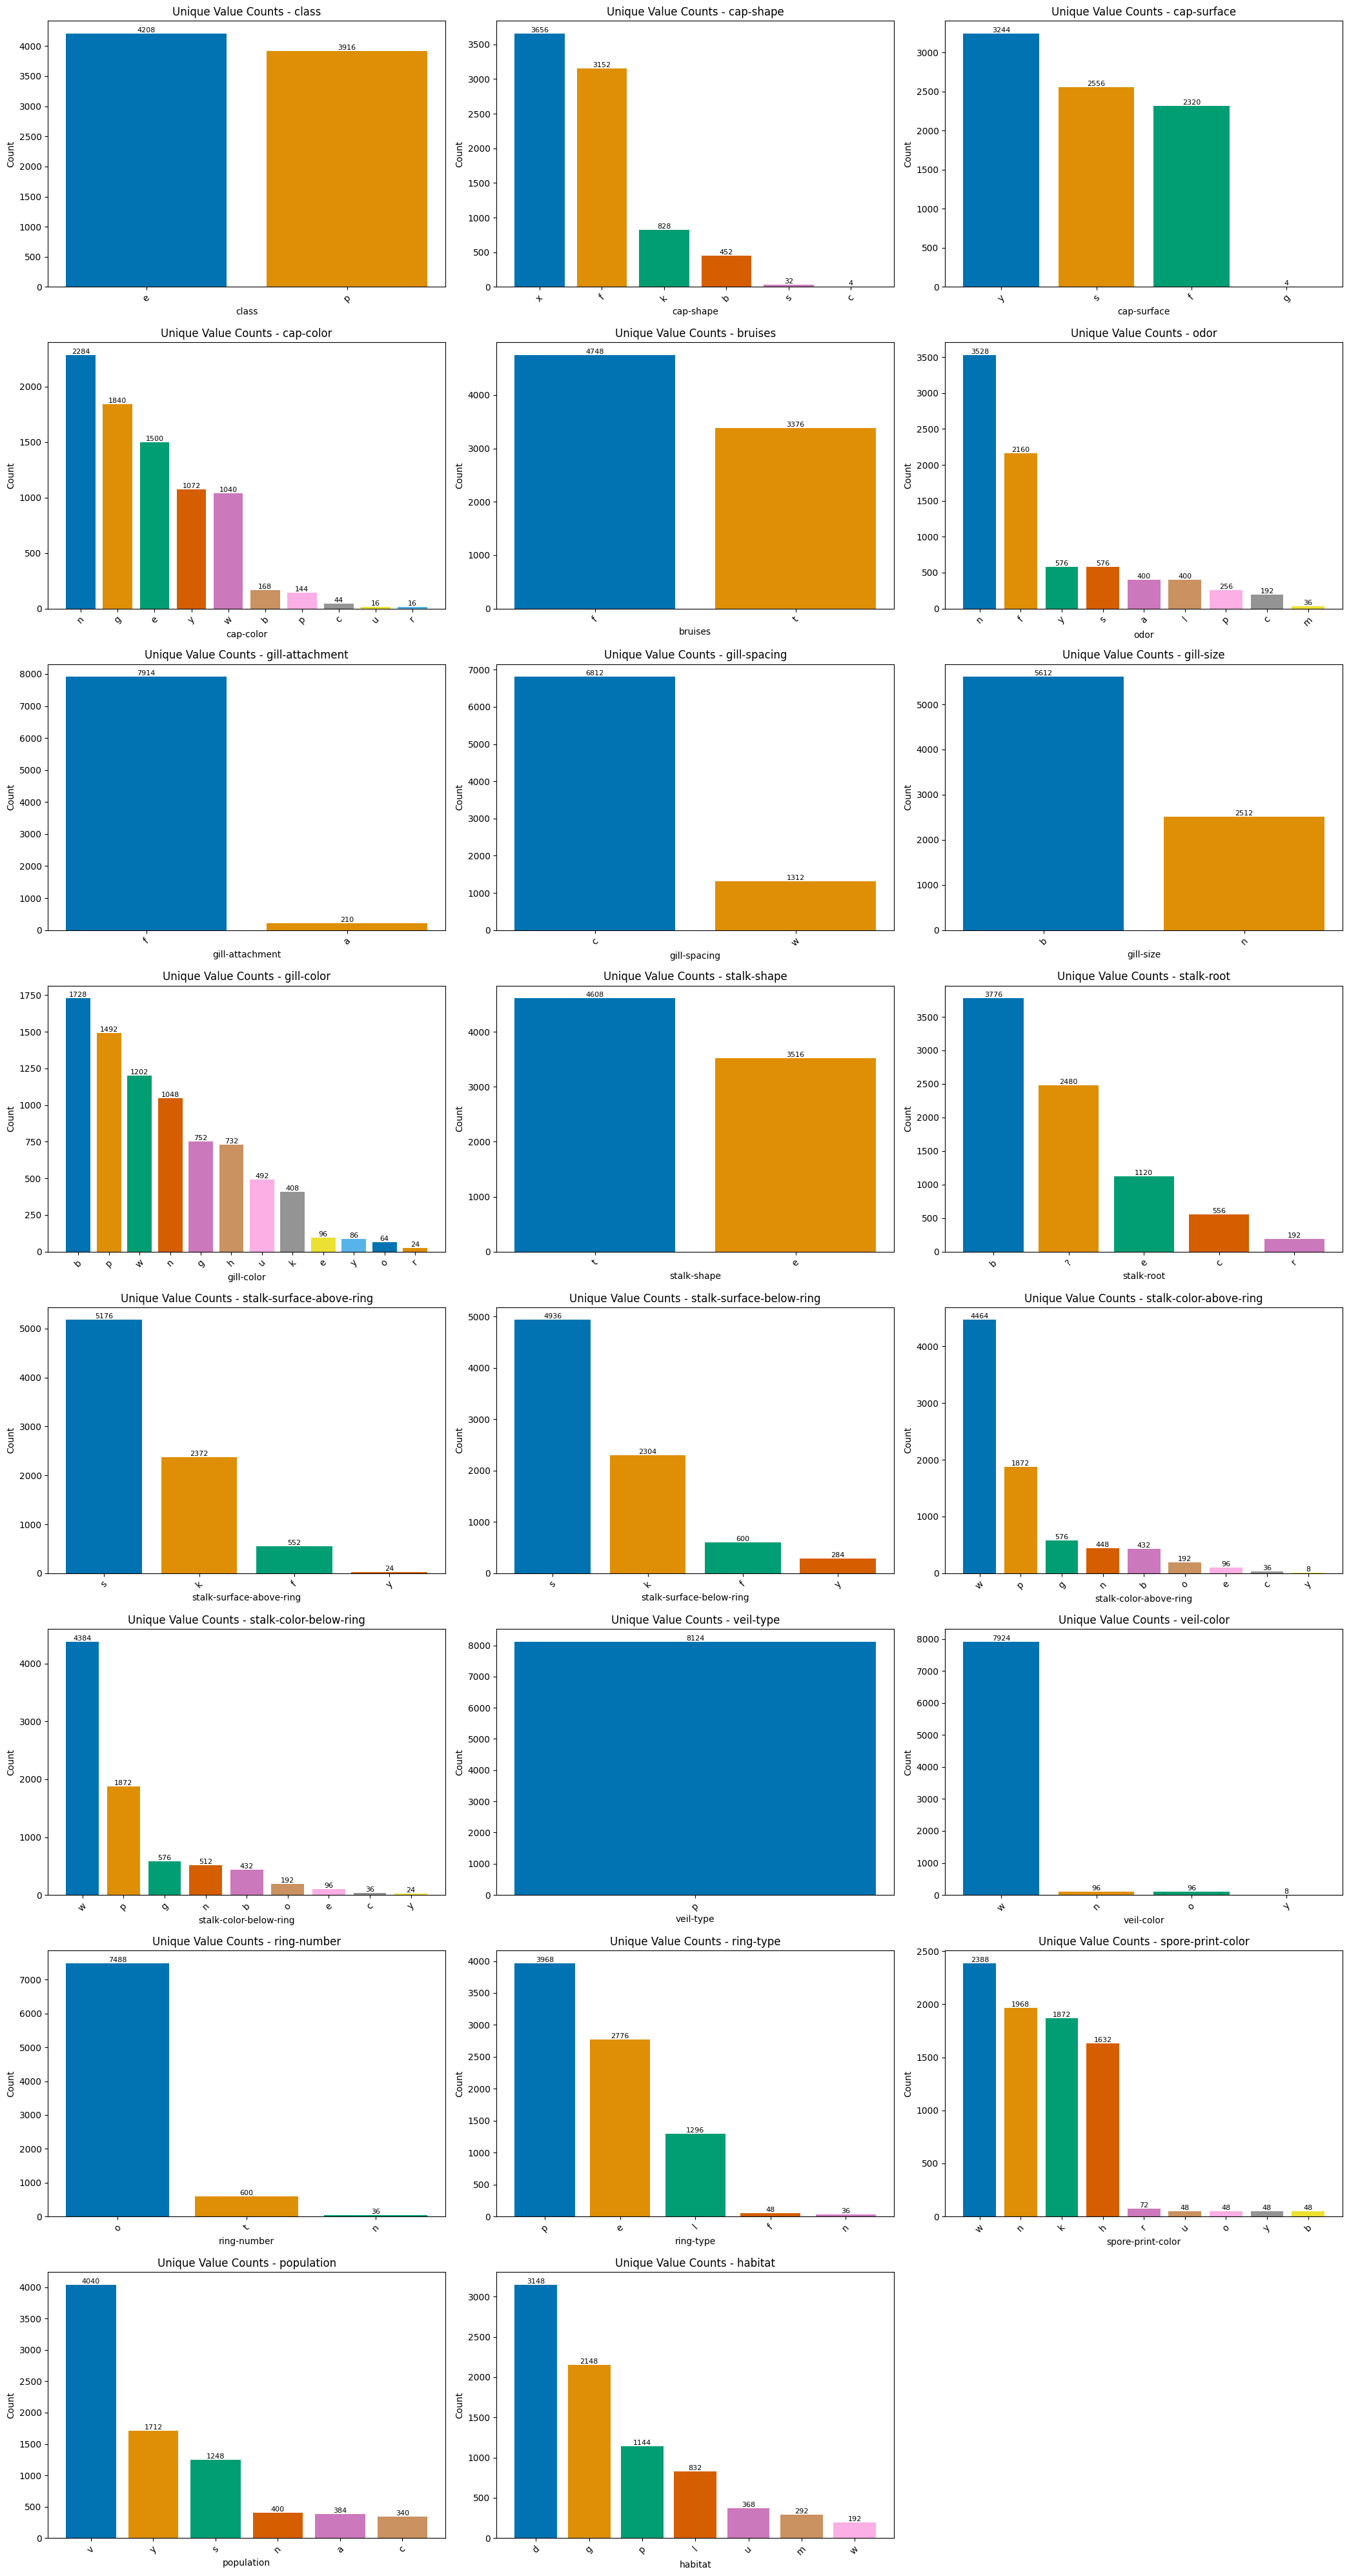

In [4]:
# Plot unique-value counts for each column.
counts_by_column = {}
for col in df_raw.columns:
    counts = df_raw[col].value_counts(dropna=False)
    counts_df = counts.rename_axis('value').reset_index(name='count')
    counts_df['value'] = counts_df['value'].astype(str)
    counts_by_column[col] = counts_df

num_cols = len(df_raw.columns)
grid_cols = 3
grid_rows = int(np.ceil(num_cols / grid_cols))

fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(7 * grid_cols, 5 * grid_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(df_raw.columns):
    ax = axes[i]
    plot_df = counts_by_column[col].copy()

    colors = sns.color_palette('colorblind', n_colors=len(plot_df))
    bars = ax.bar(plot_df['value'], plot_df['count'], color=colors)

    ax.set_title(f'Unique Value Counts - {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

    # Write count value on each bar.
    for bar, value in zip(bars, plot_df['count']):
        ax.text( bar.get_x() + bar.get_width() / 2, bar.get_height(), str(int(value)), 
                 ha='center', va='bottom', fontsize=8, rotation=0)

# Hide any unused subplot axes.
for j in range(num_cols, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [5]:
# Split first, preprocess later (fit on train only).
split_df = df_raw.copy()

y = split_df['class'].map({'e': 0, 'p': 1}).astype(int)
X = split_df.drop(columns=['class'])

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('Data split done before preprocessing.')
print('X_train_raw:', X_train_raw.shape)
print('X_test_raw:', X_test_raw.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)
print('Train class ratio (p=1):', y_train.mean())
print('Test class ratio (p=1):', y_test.mean())

Data split done before preprocessing.
X_train_raw: (6499, 22)
X_test_raw: (1625, 22)
y_train: (6499,)
y_test: (1625,)
Train class ratio (p=1): 0.4820741652561933
Test class ratio (p=1): 0.48184615384615387


## 3) Preprocessing

In [6]:
df = X_train_raw.copy()
y_train_series = pd.Series(y_train, index=X_train_raw.index)

# Keep class in original labels expected by downstream cells.
if set(y_train_series.dropna().unique()).issubset({0, 1}):
    df['class'] = y_train_series.map({0: 'e', 1: 'p'})
else:
    df['class'] = y_train_series

# Replace placeholder unknowns ?.
df = df.replace('?', np.nan)
print('\nMissing values per column before filling:')
display(df.isna().sum().sort_values(ascending=False))

# Drop duplicates.
rows_before = len(df)
df = df.drop_duplicates()
rows_after = len(df)
print(f'\nDropped {rows_before - rows_after} duplicate rows. Remaining rows: {rows_after}')


Missing values per column before filling:


stalk-root                  1968
cap-shape                      0
stalk-surface-below-ring       0
habitat                        0
population                     0
spore-print-color              0
ring-type                      0
ring-number                    0
veil-color                     0
veil-type                      0
stalk-color-below-ring         0
stalk-color-above-ring         0
stalk-surface-above-ring       0
cap-surface                    0
stalk-shape                    0
gill-color                     0
gill-size                      0
gill-spacing                   0
gill-attachment                0
odor                           0
bruises                        0
cap-color                      0
class                          0
dtype: int64


Dropped 0 duplicate rows. Remaining rows: 6499


In [7]:
# Categorical imputation for mushroom data.
df_filled = df.copy()

# Show stalk-root values before imputation (including missing)
print("\nstalk-root counts BEFORE fill:")
display(df_filled['stalk-root'].value_counts(dropna=False).rename('count').to_frame())

# Fill only stalk-root since it is the only column with missing values using mode
stalk_root_mode = df_filled['stalk-root'].mode(dropna=True)
stalk_root_fill = stalk_root_mode.iloc[0] if not stalk_root_mode.empty else 'missing'
df_filled['stalk-root'] = df_filled['stalk-root'].fillna(stalk_root_fill)

print(f'\nMissing values in stalk-root after fill: {df_filled["stalk-root"].isna().sum()}')

# Show stalk-root values after imputation 
print("\nstalk-root counts AFTER fill:")
display(df_filled['stalk-root'].value_counts(dropna=False).rename('count').to_frame())



stalk-root counts BEFORE fill:


,count
stalk-root,
b,3049
NaN,1968
e,887
c,443
r,152



Missing values in stalk-root after fill: 0

stalk-root counts AFTER fill:


,count
stalk-root,
b,5017
e,887
c,443
r,152


In [8]:
# Drop single-category features (no variance)
single_category_features = [col for col in df_filled.columns if df_filled[col].nunique() <= 1]
if single_category_features:
    df_filled = df_filled.drop(columns=single_category_features)
print(f"\nDropped features with single category: {single_category_features}")


Dropped features with single category: ['veil-type']


## 4) Outlier Detection

In [9]:
# Outlier Detection: Flag rows with rare categories (<1% frequency)
threshold = 0.01 * len(df_filled)
outlier_mask = pd.Series(False, index=df_filled.index)
outlier_details = []

for col in df_filled.columns:
    if col == 'class': continue 
    
    # Find categories appearing fewer than 'threshold' times
    counts = df_filled[col].value_counts()
    rare_cats = counts[counts < threshold].index.tolist()
    
    # 2. If any found, add to our "outlier list"
    if rare_cats:
        is_rare = df_filled[col].isin(rare_cats)
        outlier_mask |= is_rare 
        
        outlier_details.append({
            'Feature': col, 
            'Rare Values': rare_cats, 
            'Total Rows Affected': is_rare.sum()
        })

# Create the outlier tracking dataframe
outlier_df = df_filled.copy()
outlier_df['is_outlier'] = outlier_mask.astype(int)

print(f"Global Outliers Found: {outlier_mask.sum()} rows")
display(pd.DataFrame(outlier_details))

Global Outliers Found: 372 rows


,Feature,Rare Values,Total Rows Affected
0,cap-shape,"[s, c]",31
1,cap-surface,[g],3
2,cap-color,"[c, r, u]",60
3,odor,[m],27
4,gill-color,"[o, r]",70
5,stalk-surface-above-ring,[y],17
6,stalk-color-above-ring,"[c, y]",32
7,stalk-color-below-ring,"[c, y]",46
8,veil-color,[y],5
9,ring-number,[n],27


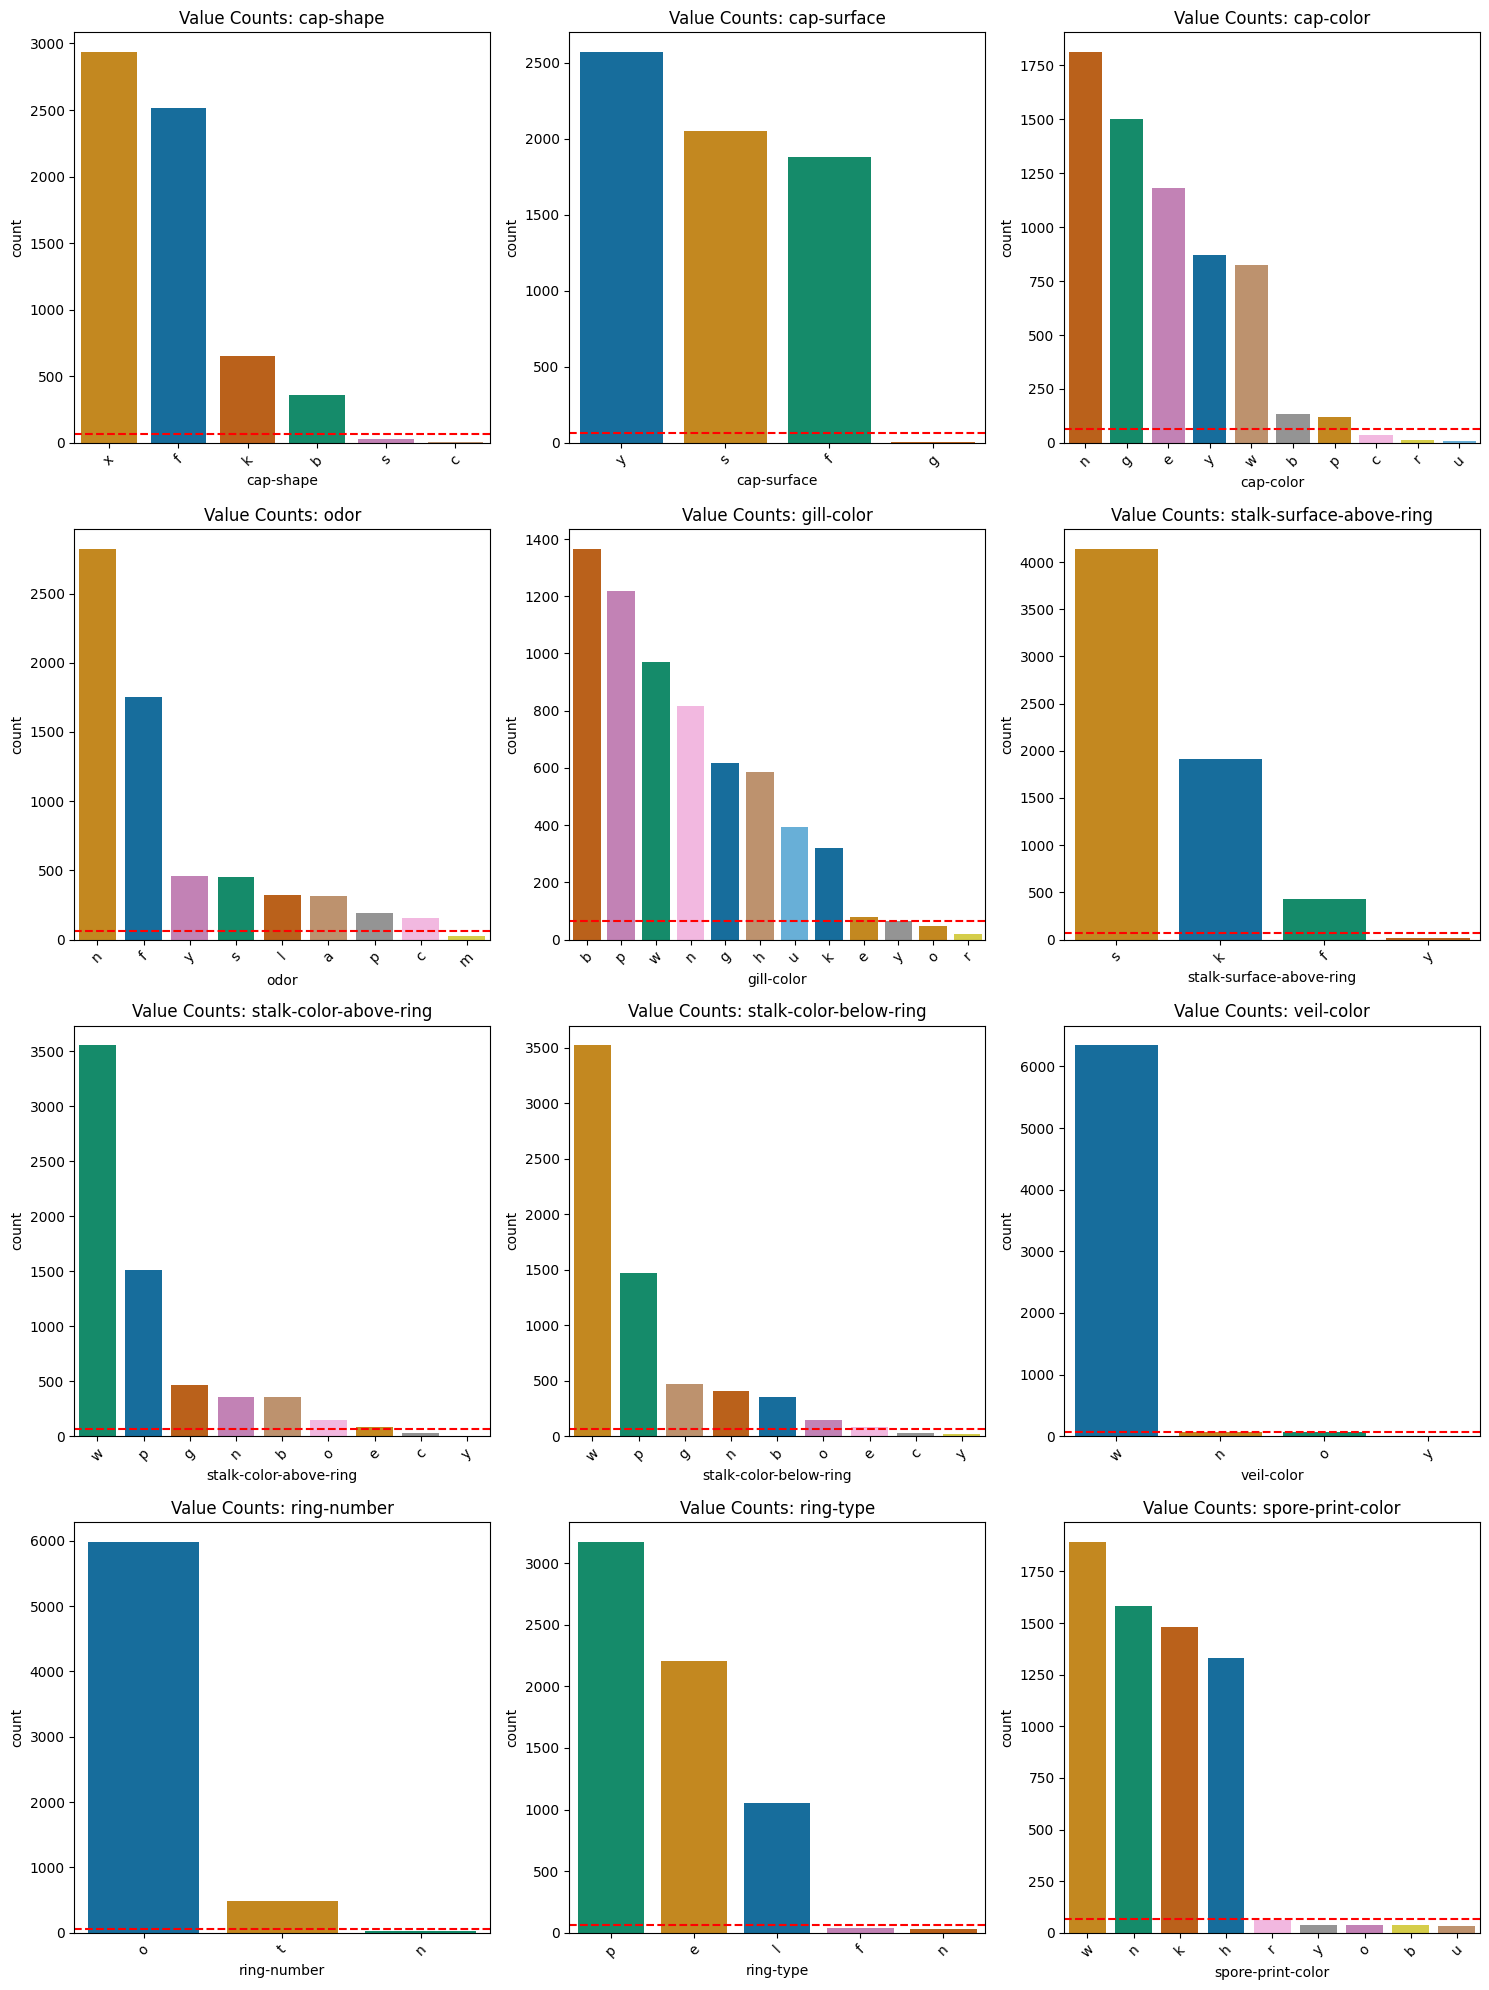

In [10]:
# Outlier Analysis Plots 
cols_with_outliers = [d['Feature'] for d in outlier_details]

n_cols = 3
n_rows = (len(cols_with_outliers) + 2) // 3 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_with_outliers):
    sns.countplot(data=df_filled, x=col, hue=col, ax=axes[i], order=df_filled[col].value_counts().index, palette='colorblind', legend=False)
    axes[i].set_title(f'Value Counts: {col}', fontsize=12)
    axes[i].axhline(y=threshold, color='r', linestyle='--', label='1% Threshold')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

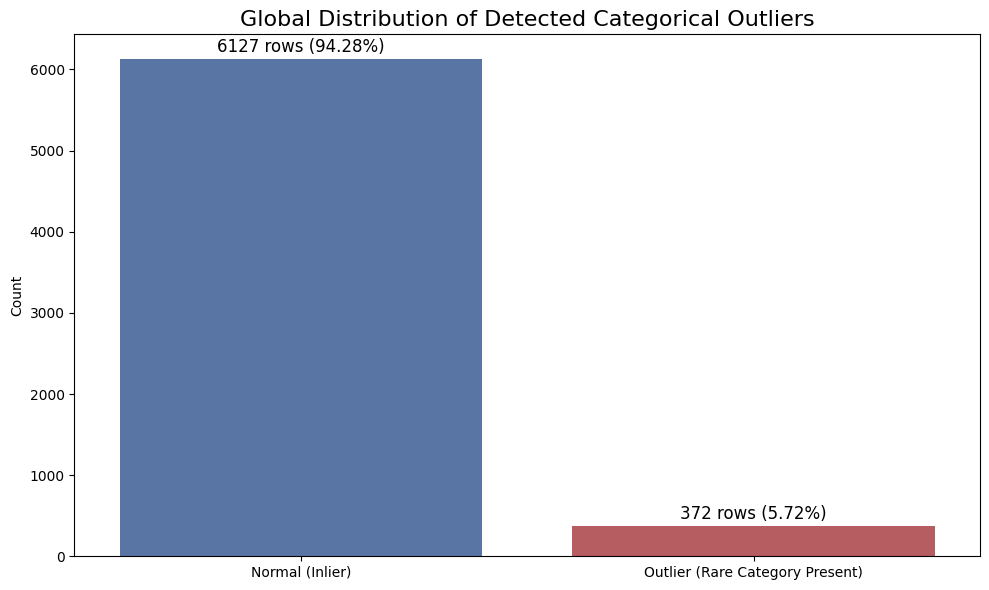

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class,is_outlier
5578,x,y,c,f,n,f,w,n,w,e,...,w,n,w,o,e,w,v,l,e,1
6434,x,s,n,f,n,a,c,b,n,e,...,o,o,n,o,p,o,v,l,e,1
8052,f,s,n,f,n,a,c,b,y,e,...,o,o,n,o,p,o,v,l,e,1
472,f,f,w,t,a,f,w,n,n,t,...,w,w,w,o,p,u,v,d,e,1
8103,k,s,n,f,n,a,c,b,y,e,...,o,o,n,o,p,o,c,l,e,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,s,f,n,f,n,f,c,n,p,e,...,w,w,w,o,p,k,y,u,e,1
5814,f,f,c,f,n,f,w,n,w,e,...,w,n,w,o,e,w,v,l,e,1
5190,f,y,p,t,n,f,c,b,w,e,...,w,w,w,t,p,r,v,g,p,1
172,x,f,y,t,l,f,w,n,n,t,...,w,w,w,o,p,u,v,d,e,1


In [11]:
# Global Dataset Outlier Distribution
plt.figure(figsize=(10, 6))
labels = ['Normal (Inlier)', 'Outlier (Rare Category Present)']
counts = outlier_df['is_outlier'].value_counts()

ax = sns.barplot(x=labels, y=counts, hue=labels, palette=['#4C72B0', '#C44E52'], legend=False)
plt.title('Global Distribution of Detected Categorical Outliers', fontsize=16)
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} rows ({p.get_height()/len(outlier_df)*100:.2f}%)', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', xytext = (0, 9), 
                textcoords = 'offset points', fontsize=12)

plt.tight_layout()
plt.show()

# Rows containing outliers 
display(outlier_df[outlier_df['is_outlier'] == 1])

## 5) Data Assessment and Correlation

In [12]:
# Choose Data Subset for Analysis
df_analysis = outlier_df[outlier_df['is_outlier'] == 0].drop(columns=['is_outlier'])
print(f"Dataset for assessment: {df_analysis.shape[0]} rows and {df_analysis.shape[1]} features.")

# Association Functions
def associations_matrix(df):
    cols = df.columns
    n = len(cols)
    cv_mtx = pd.DataFrame(np.zeros((n, n)), index=cols, columns=cols)
    tu_mtx = pd.DataFrame(np.zeros((n, n)), index=cols, columns=cols)

    for i in range(n):
        for j in range(n):
            if i == j:
                cv_mtx.iloc[i, j] = 1.0
                tu_mtx.iloc[i, j] = 1.0
                continue
            
            c1, c2 = cols[i], cols[j]
            contingency = pd.crosstab(df[c1], df[c2])
            
            # Cramer's V (Symmetric)
            chi2 = chi2_contingency(contingency)[0]
            n_obs = contingency.sum().sum()
            r, k = contingency.shape
            cv_mtx.iloc[i, j] = np.sqrt(chi2 / (n_obs * min(k-1, r-1))) if n_obs > 0 and min(k-1, r-1) > 0 else 0
            
            # Theil's U (Asymmetric: how much X=c1 tells us about Y=c2)
            pxy = contingency / n_obs
            px = pxy.sum(axis=1)
            py = pxy.sum(axis=0)
            h_y = entropy(py, base=2)
            h_xy = entropy(pxy.values.flatten(), base=2)
            h_y_given_x = h_xy - entropy(px, base=2)
            tu_mtx.iloc[i, j] = (h_y - h_y_given_x) / h_y if h_y > 0 else 0

    return cv_mtx, tu_mtx

cramer_matrix, theils_matrix = associations_matrix(df_analysis)

Dataset for assessment: 6127 rows and 22 features.


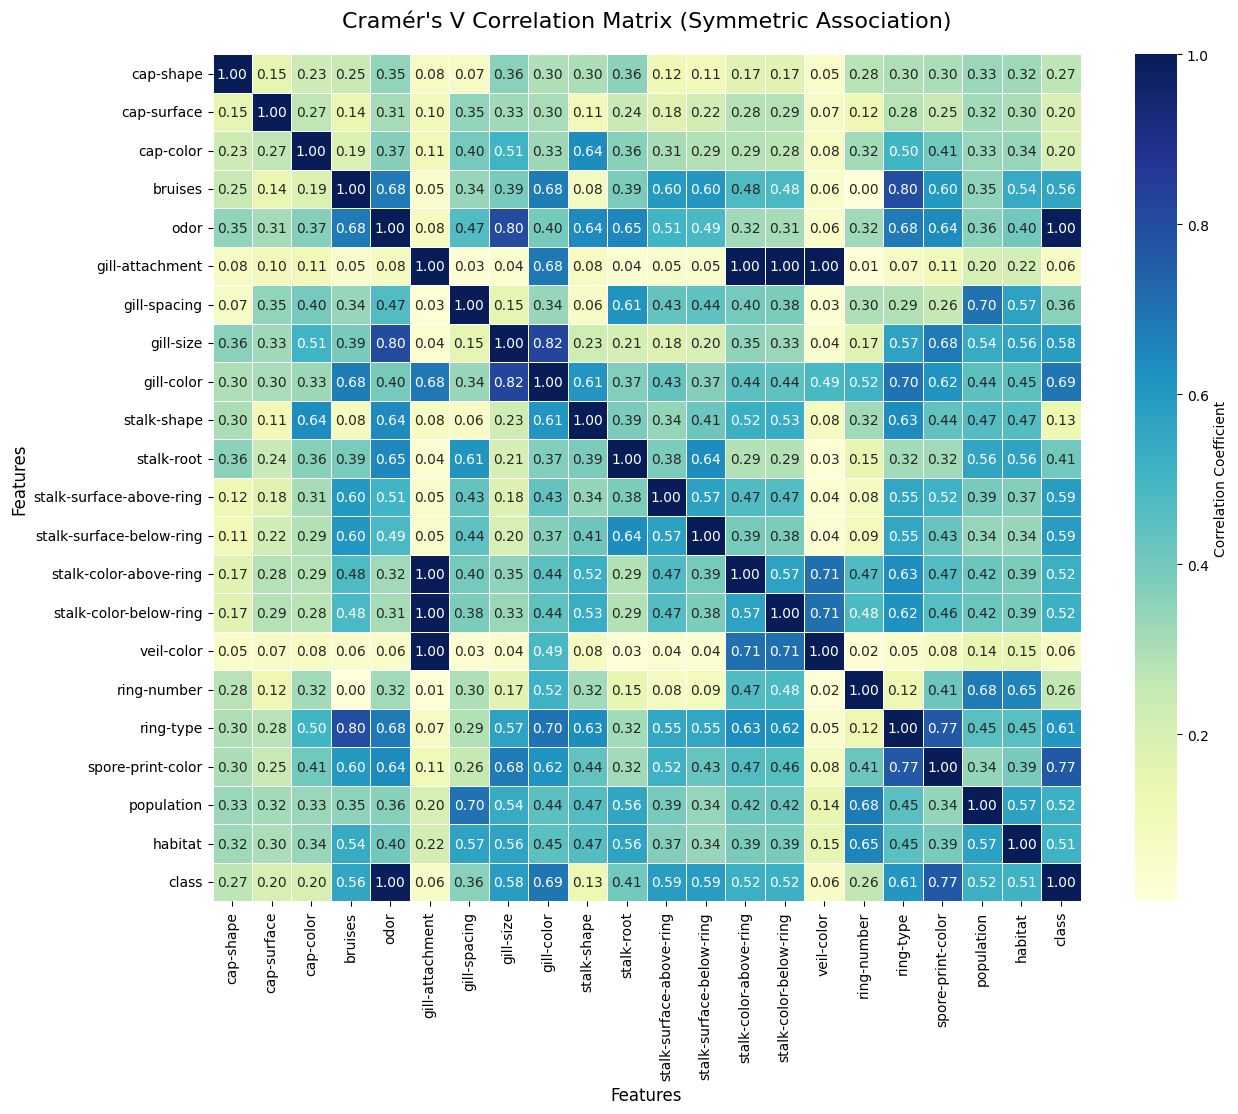


Top 10 correlated feature pairs based on Cramér's V:
  - gill-attachment ↔ stalk-color-above-ring: 1.000
  - gill-attachment ↔ stalk-color-below-ring: 1.000
  - gill-attachment ↔ veil-color: 1.000
  - odor ↔ class: 0.996
  - gill-size ↔ gill-color: 0.823
  - odor ↔ gill-size: 0.802
  - bruises ↔ ring-type: 0.801
  - ring-type ↔ spore-print-color: 0.768
  - spore-print-color ↔ class: 0.766
  - stalk-color-below-ring ↔ veil-color: 0.707


In [13]:
# Association Visualization: Cramér's V (Symmetric)
plt.figure(figsize=(14, 11))
sns.heatmap(cramer_matrix, cmap='YlGnBu', annot=True, fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Cramér\'s V Correlation Matrix (Symmetric Association)', fontsize=16, pad=20)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

# List Top Correlated Feature Pairs
pairs = []
for i in range(len(cramer_matrix.columns)):
    for j in range(i+1, len(cramer_matrix.columns)):
        pairs.append((cramer_matrix.columns[i], cramer_matrix.columns[j], cramer_matrix.iloc[i, j]))

# Print top 10 most correlated pairs
print("\nTop 10 correlated feature pairs based on Cramér's V:")
for f1, f2, corr in sorted(pairs, key=lambda x: x[2], reverse=True)[:10]:
    print(f"  - {f1} ↔ {f2}: {corr:.3f}")

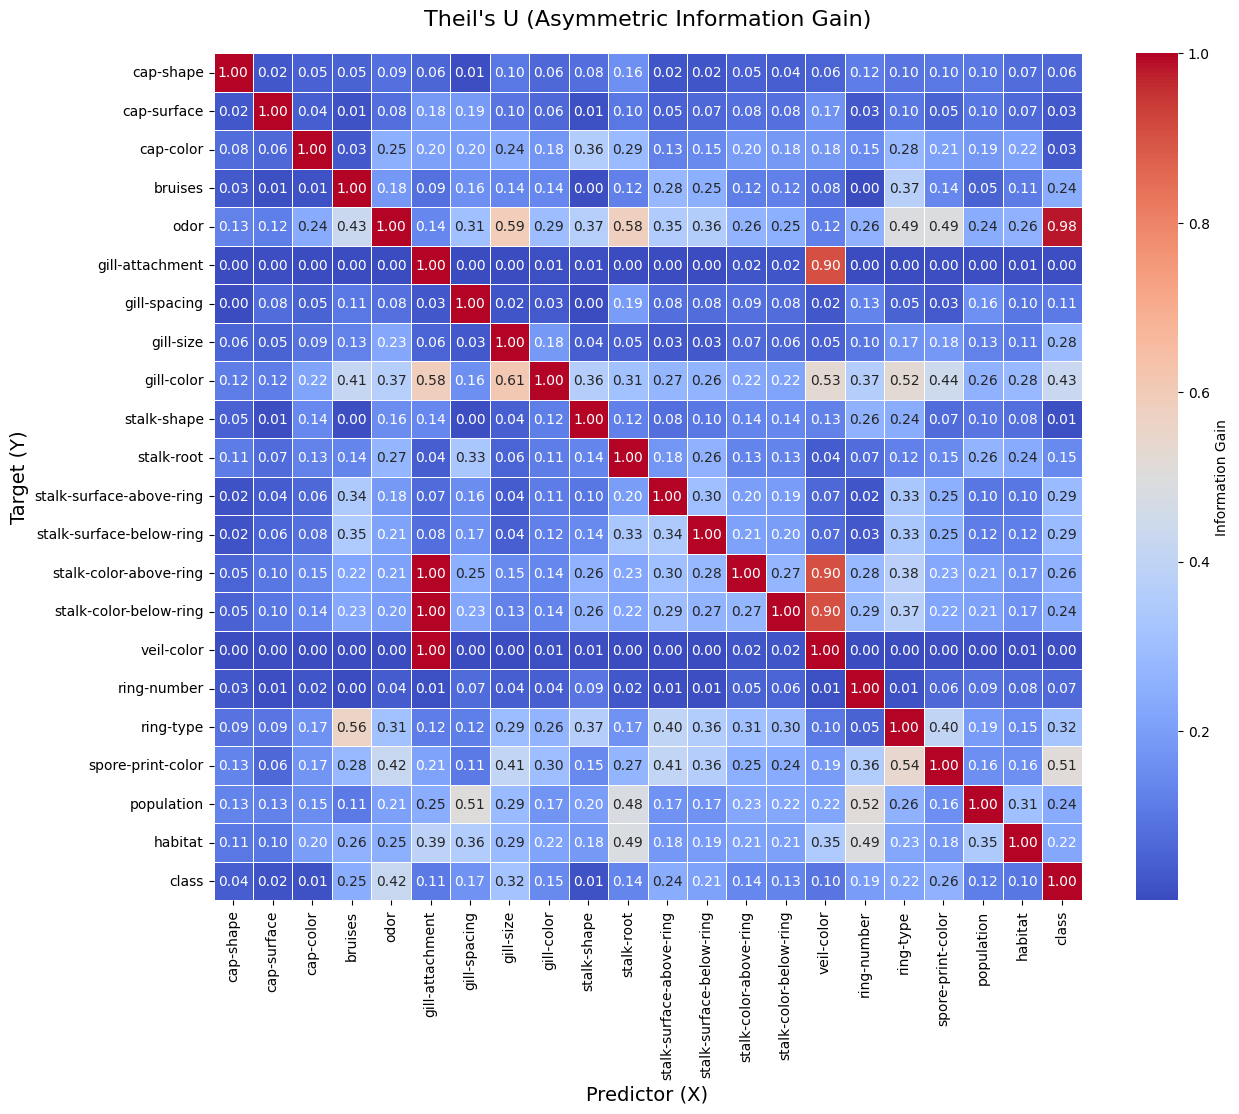


Predictive Insight (X provides more than 50% Information Gain about Y):
  - ring-type provides 55.96% information about bruises
  - stalk-color-above-ring provides 100.00% information about gill-attachment
  - population provides 50.59% information about gill-spacing
  - gill-color provides 61.24% information about gill-size
  - odor provides 58.10% information about stalk-root
  - gill-attachment provides 90.35% information about veil-color
  - population provides 51.50% information about ring-number
  - spore-print-color provides 54.28% information about ring-type
  - odor provides 98.08% information about class


In [14]:
# Association Visualization: Theil's U (Asymmetric)
plt.figure(figsize=(14, 11))
sns.heatmap(theils_matrix, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Information Gain'})
plt.title('Theil\'s U (Asymmetric Information Gain)', fontsize=16, pad=20)
plt.xlabel('Predictor (X)', fontsize=14)
plt.ylabel('Target (Y)', fontsize=14)
plt.show()

# Print specific insights for Theil's U (Information Gain > 50%)
print("\nPredictive Insight (X provides more than 50% Information Gain about Y):")
for col_y in theils_matrix.columns:
    strong_predictors = theils_matrix.loc[theils_matrix.index != col_y, col_y]
    max_feat = strong_predictors.idxmax()
    max_val = strong_predictors[max_feat]
    if max_val > 0.5:
        print(f"  - {max_feat} provides {max_val:.2%} information about {col_y}")

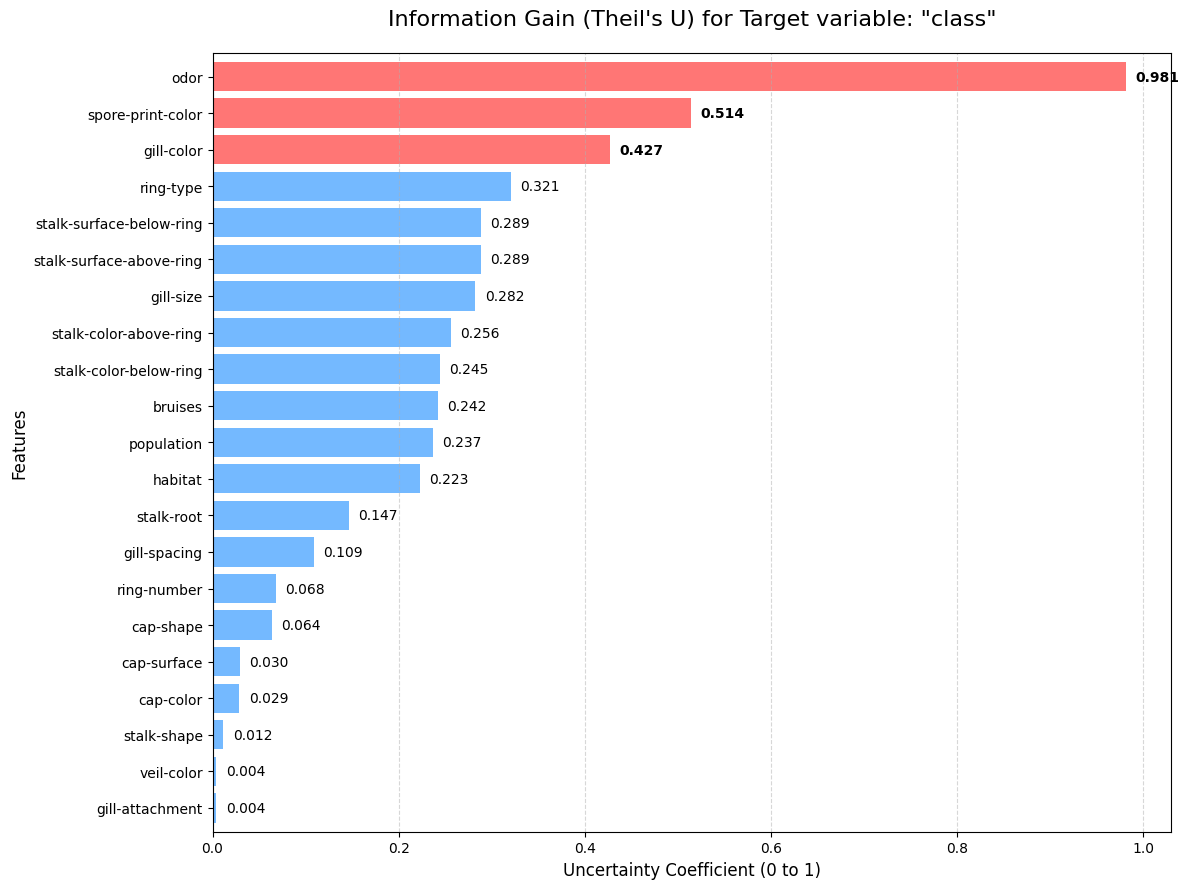

Top informers for mushroom toxicity ('class'):
  1. odor provides 98.08% information about poisoning status.
  2. spore-print-color provides 51.37% information about poisoning status.
  3. gill-color provides 42.71% information about poisoning status.
  4. ring-type provides 32.07% information about poisoning status.
  5. stalk-surface-below-ring provides 28.87% information about poisoning status.


In [15]:
# Target Specific Importance for 'class' (poisoning status)
target_importances = theils_matrix['class'].drop('class').sort_values(ascending=False)

plt.figure(figsize=(12, 9))
# Use dual-color palette for emphasis: top 3 are coral, others are skyblue
colors = ['#ff7675' if i < 3 else '#74b9ff' for i in range(len(target_importances))]
ax = target_importances.plot(kind='barh', color=colors, width=0.8)

plt.title('Information Gain (Theil\'s U) for Target variable: "class"', fontsize=16, pad=20)
plt.xlabel('Uncertainty Coefficient (0 to 1)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.gca().invert_yaxis()  # Put most informative on top
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Add value annotations to each bar
for i, v in enumerate(target_importances):
    plt.text(v + 0.01, i, f"{v:.3f}", color='black', va='center', fontweight='bold' if i < 3 else 'normal')

plt.tight_layout()
plt.show()
plt.close('all')

# Print Top Informers Summary
print(f"Top informers for mushroom toxicity ('class'):")
for i, (feat, val) in enumerate(target_importances[:5].items()):
    print(f"  {i+1}. {feat} provides {val:.2%} information about poisoning status.")

In [16]:
# Theil's U measures directional information gain between categorical variables.
# - High Theil's U from a feature to 'class' means that feature is useful for predicting edible/poisonous.
# - Low Theil's U means the feature adds little information about the target and can be considered for removal.
# Cramér's V measures symmetric association between categorical features.
# - High Cramér's V between two predictors means they are redundant or very similar.
# - In that case, it is usually better to keep the one with the stronger Theil's U to 'class'.

target_col = 'class'
low_info_threshold = 0.05
high_assoc_threshold = 0.90

# Start from the current analyzed dataset so this cell can run on its own.
df_model = outlier_df[outlier_df['is_outlier'] == 0].drop(columns=['is_outlier']).copy()

# Use Theil's U to find features that are weak predictors of the target.
target_scores = theils_matrix[target_col].drop(target_col).sort_values(ascending=False)
weak_features = target_scores[target_scores < low_info_threshold].index.tolist()

# Use Cramér's V to find highly redundant feature pairs, then keep the feature
# that is more informative about 'class'.
redundant_to_drop = set()
feature_cols = [c for c in cramer_matrix.columns if c != target_col]
for i, left in enumerate(feature_cols):
    for right in feature_cols[i + 1:]:
        assoc = cramer_matrix.loc[left, right]
        if assoc >= high_assoc_threshold:
            left_score = target_scores.get(left, 0.0)
            right_score = target_scores.get(right, 0.0)
            if left_score > right_score:
                redundant_to_drop.add(right)
            elif right_score > left_score:
                redundant_to_drop.add(left)
            else:
                redundant_to_drop.add(right)

columns_to_drop = sorted(set(weak_features).union(redundant_to_drop))

print('Matrix interpretation:')
print('  Theil\'s U tells how much each feature reduces uncertainty about the target.')
print('  Cramér\'s V tells how strongly pairs of categorical features move together.')
print('')
print(f'Using thresholds -> low Theil\'s U < {low_info_threshold:.2f}, high Cramér\'s V >= {high_assoc_threshold:.2f}')
print(f'Weak target predictors: {weak_features if weak_features else []}')
print(f'Redundant features suggested by Cramér\'s V: {sorted(redundant_to_drop) if redundant_to_drop else []}')
print(f'Columns to drop: {columns_to_drop if columns_to_drop else []}')

if columns_to_drop:
    df_model = df_model.drop(columns=columns_to_drop).copy()
    outlier_df = outlier_df.drop(columns=columns_to_drop).copy()
    print(f'Updated df_model shape: {df_model.shape}')
    print(f'Updated outlier_df shape: {outlier_df.shape}')
else:
    print('No columns met the removal thresholds, so df_model was left unchanged.')

Matrix interpretation:
  Theil's U tells how much each feature reduces uncertainty about the target.
  Cramér's V tells how strongly pairs of categorical features move together.

Using thresholds -> low Theil's U < 0.05, high Cramér's V >= 0.90
Weak target predictors: ['cap-surface', 'cap-color', 'stalk-shape', 'veil-color', 'gill-attachment']
Redundant features suggested by Cramér's V: ['gill-attachment', 'veil-color']
Columns to drop: ['cap-color', 'cap-surface', 'gill-attachment', 'stalk-shape', 'veil-color']
Updated df_model shape: (6127, 17)
Updated outlier_df shape: (6499, 18)


## 6) Categorical Encoding (One Hot Encoding)

Encoding Summary:
  Train raw shape: (6127, 16), Test raw shape: (1625, 16)
  Train encoded shape: (6127, 75), Test encoded shape: (1625, 75)
  Target encoding: e -> 0, p -> 1
  Train class balance (p=1): 0.493
  Test class balance (p=1): 0.482


,cap-shape_b,cap-shape_f,cap-shape_k,cap-shape_x,bruises_f,bruises_t,odor_a,odor_c,odor_f,odor_l,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
5249,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5781,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
7586,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6181,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
7338,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3760,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
409,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5103,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3523,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1050,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


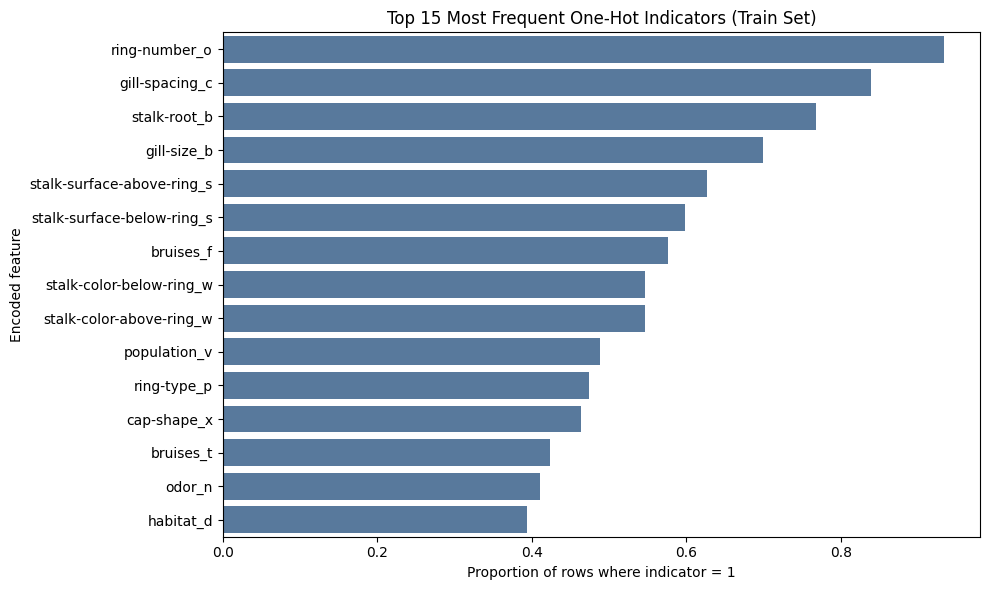

In [17]:
# Train set after preprocessing/outlier handling/correlation-based feature pruning
train_df = df_model.copy()

leakage_cols = [c for c in ['class_encoded'] if c in train_df.columns]
if leakage_cols:
    train_df = train_df.drop(columns=leakage_cols)
    print(f"Removed leakage-prone columns from train: {leakage_cols}")

y_train = train_df['class'].map({'e': 0, 'p': 1}).astype(int)
X_train = train_df.drop(columns=['class'])

# Prepare TEST using train-derived preprocessing choices only (no fit on test).
X_test = X_test_raw.copy()
X_test = X_test.replace('?', np.nan)

if 'stalk-root' in X_test.columns and 'stalk_root_fill' in globals():
    X_test['stalk-root'] = X_test['stalk-root'].fillna(stalk_root_fill)

drop_from_test = []
if 'single_category_features' in globals():
    drop_from_test.extend([c for c in single_category_features if c in X_test.columns and c != 'class'])
if 'columns_to_drop' in globals():
    drop_from_test.extend([c for c in columns_to_drop if c in X_test.columns and c != 'class'])
if drop_from_test:
    X_test = X_test.drop(columns=sorted(set(drop_from_test)))

# Align test columns to train columns exactly.
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# One-Hot encode categorical features (fit on train only, transform test).
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_ohe = ohe.fit_transform(X_train)
X_test_ohe = ohe.transform(X_test)
feature_names_ohe = ohe.get_feature_names_out(X_train.columns)

# Convert to DataFrames for readability
X_train_encoded = pd.DataFrame(X_train_ohe, columns=feature_names_ohe, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_ohe, columns=feature_names_ohe, index=X_test.index)

print('Encoding Summary:')
print(f'  Train raw shape: {X_train.shape}, Test raw shape: {X_test.shape}')
print(f'  Train encoded shape: {X_train_encoded.shape}, Test encoded shape: {X_test_encoded.shape}')
print('  Target encoding: e -> 0, p -> 1')
print(f'  Train class balance (p=1): {y_train.mean():.3f}')
print(f'  Test class balance (p=1): {y_test.mean():.3f}')

# Show a quick sample of encoded features
display(X_train_encoded.head(10))

# Most frequent one-hot encoded indicators in train data
feature_prevalence = X_train_encoded.mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_prevalence.values, y=feature_prevalence.index, color='#4C78A8')
plt.title('Top 15 Most Frequent One-Hot Indicators (Train Set)')
plt.xlabel('Proportion of rows where indicator = 1')
plt.ylabel('Encoded feature')
plt.tight_layout()
plt.show()
plt.close('all')

## 7) Random Forest Classifier

In [18]:
model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X_train_encoded, y_train)
y_pred = model.predict(X_test_encoded)
y_proba = model.predict_proba(X_test_encoded)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
prec, rec, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc,
    'avg_precision': ap,
}
print('\nFinal Random Forest metrics:')
display(pd.Series(metrics).round(4).to_frame('value'))
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['edible', 'poisonous']))


Final Random Forest metrics:


,value
accuracy,0.9822
precision,0.9922
recall,0.9706
f1,0.9813
roc_auc,0.9990
avg_precision,0.9990



Classification report:
              precision    recall  f1-score   support

      edible       0.97      0.99      0.98       842
   poisonous       0.99      0.97      0.98       783

    accuracy                           0.98      1625
   macro avg       0.98      0.98      0.98      1625
weighted avg       0.98      0.98      0.98      1625



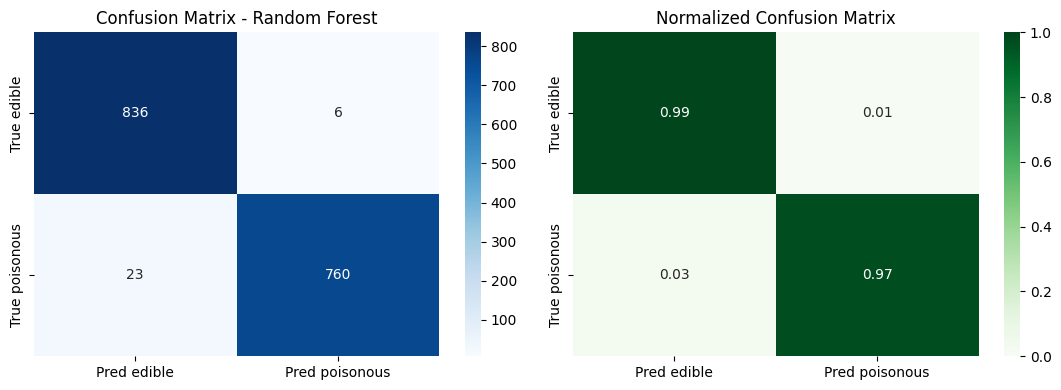

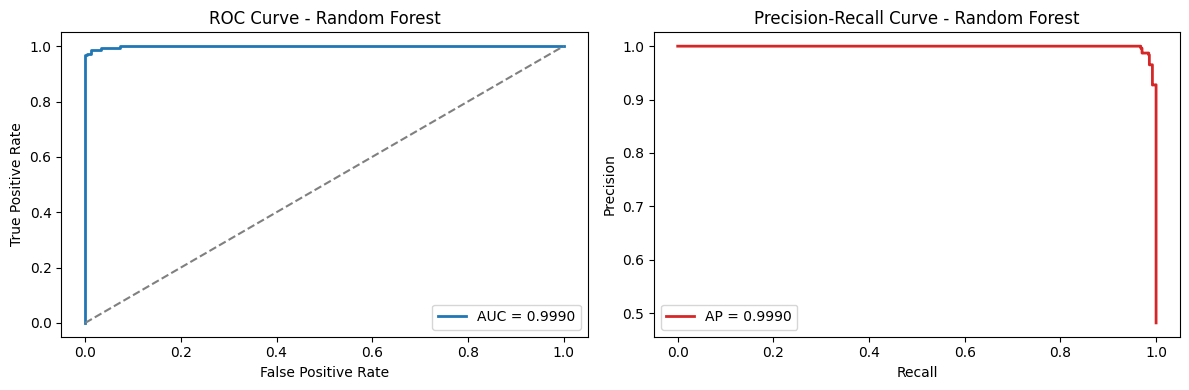

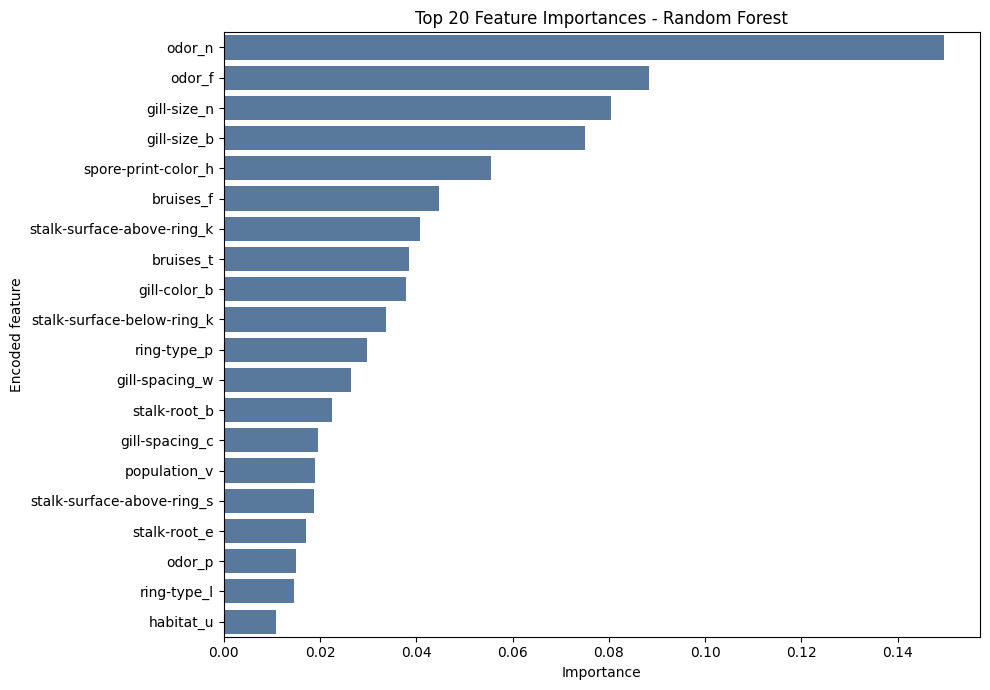

In [19]:
# Visualization cell
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred edible', 'Pred poisonous'], yticklabels=['True edible', 'True poisonous'], ax=axes[0])
axes[0].set_title('Confusion Matrix - Random Forest')

cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', vmin=0, vmax=1, xticklabels=['Pred edible', 'Pred poisonous'], yticklabels=['True edible', 'True poisonous'], ax=axes[1])
axes[1].set_title('Normalized Confusion Matrix')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fpr, tpr, color='#1f77b4', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title('ROC Curve - Random Forest')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

axes[1].plot(rec, prec, color='#d62728', lw=2, label=f'AP = {ap:.4f}')
axes[1].set_title('Precision-Recall Curve - Random Forest')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left')
plt.tight_layout()
plt.show()

feat_imp = pd.Series(model.feature_importances_, index=X_train_encoded.columns)
top_imp = feat_imp.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_imp.values, y=top_imp.index, color='#4C78A8')
plt.title('Top 20 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Encoded feature')
plt.tight_layout()
plt.show()